# Análise Exploratória dos Dados

Antes de construir qualquer modelo de aprendizado de máquina, é fundamental compreender o conjunto de dados. A Análise Exploratória dos Dados (EDA) nos ajuda a inspecionar os atributos disponíveis, identificar problemas de qualidade dos dados, compreender a distribuição das variáveis e investigar quais características dos passageiros parecem estar associadas à sobrevivência.

Neste notebook iremos:

* Carregar os conjuntos de treinamento e de teste.
* Inspecionar sua estrutura e conteúdo.
* Examinar valores ausentes e tipos de dados.
* Explorar a distribuição da variável alvo.
* Analisar a relação entre as características dos passageiros e a sobrevivência.
* Identificar oportunidades para engenharia de atributos na próxima etapa.

Ao final deste notebook, teremos uma compreensão sólida dos dados e um plano claro para prepará-los para os modelos de aprendizado de máquina.

---

## Descrição do conjunto de dados

O conjunto de treinamento contém uma linha para cada passageiro e as seguintes variáveis:

| Atributo   | Descrição                                                                                                                                                     |
| ---------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `Survived` | Variável alvo. `0` indica que o passageiro não sobreviveu, enquanto `1` indica que sobreviveu. Esta coluna está disponível apenas no conjunto de treinamento. |
| `Pclass`   | Classe da passagem (`1` = Primeira Classe, `2` = Segunda Classe, `3` = Terceira Classe).                                                                      |
| `Name`     | Nome completo do passageiro.                                                                                                                                  |
| `Sex`      | Sexo do passageiro (`male` ou `female`).                                                                                                                      |
| `Age`      | Idade do passageiro em anos. Valores fracionários representam bebês, enquanto idades terminadas em `.5` correspondem a estimativas.                           |
| `SibSp`    | Número de irmãos e cônjuges a bordo do Titanic.                                                                                                               |
| `Parch`    | Número de pais e filhos a bordo do Titanic. Crianças viajando apenas com uma babá possuem `Parch = 0`.                                                        |
| `Ticket`   | Número da passagem.                                                                                                                                           |
| `Fare`     | Valor da passagem.                                                                                                                                            |
| `Cabin`    | Identificador da cabine. Muitos valores estão ausentes.                                                                                                       |
| `Embarked` | Porto de embarque (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).                                                                                     |

As variáveis `SibSp` e `Parch` merecem um breve esclarecimento. No contexto deste conjunto de dados:

* `Sibling` inclui irmão, irmã, meio-irmão e meia-irmã.
* `Spouse` inclui marido e esposa (noivos e amantes não são considerados).
* `Parent` inclui mãe e pai.
* `Child` inclui filha, filho, enteada e enteado.

## Importações

Primeiro, importamos as bibliotecas que serão utilizadas ao longo da análise.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## Carregando os dados

O conjunto de dados está dividido em um conjunto de treinamento e um conjunto de teste. O conjunto de treinamento inclui a variável alvo (`Survived`), que desejamos prever, enquanto o conjunto de teste contém apenas os atributos de entrada e é utilizado para gerar a submissão final ao Kaggle.

Começamos carregando ambos os conjuntos de dados e realizando uma inspeção inicial. Isso inclui verificar as dimensões dos conjuntos de dados, confirmar a consistência dos nomes dos atributos entre os conjuntos de treinamento e de teste, e procurar possíveis problemas, como linhas duplicadas ou inconsistências estruturais evidentes.

In [2]:
df_test = pd.read_csv("../data/raw/test.csv")
df_train = pd.read_csv("../data/raw/train.csv")

print(
f"""
--------------------
Train set:

{df_train.shape[0]} rows
{df_train.duplicated().sum()} duplicated rows
{df_train.shape[1]} columns
--------------------
Test set:

{df_test.shape[0]} rows
{df_test.duplicated().sum()} duplicated rows
{df_test.shape[1]} columns
--------------------
Columns train/test:
{[column for column in df_train.columns if column in df_test.columns]}

Target variable (only in test):
{[column for column in df_train.columns if column not in df_test.columns]}
--------------------
"""
)


--------------------
Train set:

891 rows
0 duplicated rows
12 columns
--------------------
Test set:

418 rows
0 duplicated rows
11 columns
--------------------
Columns train/test:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Target variable (only in test):
['Survived']
--------------------



In [3]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# All features minus the tareget
features = [column for column in df_test.columns if column not in ("PassengerId", "Survived")]

# feature description dataframe
df_features = pd.DataFrame({
    "Name": features,
    "Type": ["numerical" if pd.api.types.is_numeric_dtype(df_test[column]) else "categorical" for column in features],
    "Category":["original"]*len(features),
    "Source":features,
})

feature_to_description = {
    "Survived": "Target variable. `0` indicates the passenger did not survive, while `1` indicates survival. This column is only available in the training set.",
    "Pclass": "Passenger ticket class (`1` = First, `2` = Second, `3` = Third).",
    "Name": "Passenger's full name.",
    "Sex": "Passenger's sex (`male` or `female`).",
    "Age": "Passenger's age in years. Fractional values represent infants, while values ending in `.5` correspond to estimated ages.",
    "SibSp": "Number of siblings and spouses aboard the Titanic.",
    "Parch": "Number of parents and children aboard the Titanic. Children traveling only with a nanny have `Parch = 0`.",
    "Ticket": "Ticket number.",
    "Fare": "Passenger fare.",
    "Cabin": "Cabin identifier. Many values are missing.",
    "Embarked": "Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton).",
}

df_features["Description"] = df_features["Name"].map(feature_to_description)

df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Cabin,categorical,original,Cabin,Cabin identifier. Many values are missing.
9,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


In [6]:
# Train/Test split
df_train["IsTrainSet"] = True
df_test["IsTrainSet"] = False

df_full = pd.concat(
    [df_train, df_test],
    axis=0,
    ignore_index=True
)

print(
    f"""
    Full dataset ( train + test ):

    {df_full.shape[0]} rows
    {df_full.duplicated().sum()} duplicated rows
    {df_full.shape[1]} columns
    """
)

df_full


    Full dataset ( train + test ):

    1309 rows
    0 duplicated rows
    13 columns
    


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsTrainSet
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,False
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,False
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,False
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,False


Para começar a nos familiarizar com os dados disponíveis, podemos utilizar os métodos `info()` e `describe()` para obter informações sobre os tipos de dados, valores ausentes e estatísticas descritivas gerais, como média, mediana, valores máximo e mínimo, entre outras.

In [7]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
 12  IsTrainSet   1309 non-null   bool   
dtypes: bool(1), float64(3), int64(4), object(5)
memory usage: 124.1+ KB


In [8]:
df_full.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


## Valores faltantes

Antes de prosseguir com a análise, gosto de inspecionar visualmente a quantidade de valores faltantes presente no conjunto de dados.

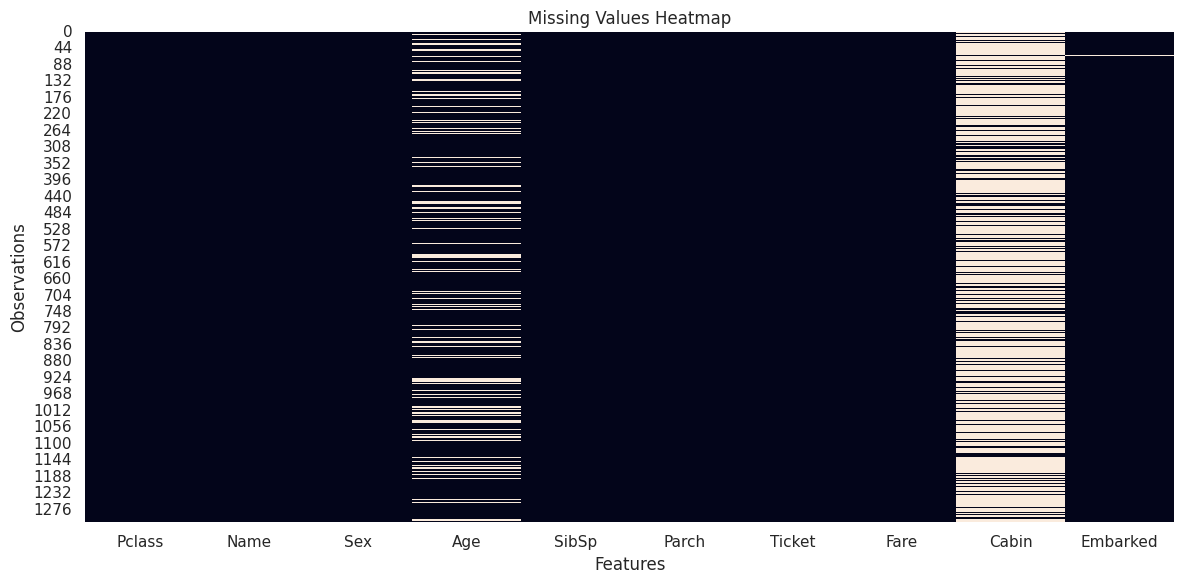

In [9]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df_full[features].isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Observations")

plt.tight_layout()
plt.show()

O mapa de calor acima mostra que o conjunto de dados contém relativamente poucos valores faltantes. A maioria dos atributos está completa, sendo necessário dar atenção apenas a três colunas:

* `Cabin` apresenta uma grande proporção de valores faltantes. Como a maior parte dos registros está indisponível, esse atributo será excluído da análise.
* `Embarked` possui apenas alguns valores faltantes, que serão preenchidos com o porto de embarque mais frequente.
* `Age` contém uma quantidade moderada de valores faltantes. Como a idade provavelmente é um atributo informativo para prever a sobrevivência, iremos imputar os valores faltantes em vez de descartar as linhas afetadas. Antes de definir a estratégia de imputação, analisaremos como a mediana da idade varia entre diferentes grupos de passageiros para determinar se é mais apropriado utilizar uma mediana global ou uma mediana específica para cada grupo.

Para confirmar essa observação, também podemos contar o número de atributos que contêm valores faltantes e comparar o resultado com as informações apresentadas no mapa de calor.

In [10]:
df_full.isna().sum().loc[
    lambda x: x > 0
].sort_values(ascending=False)

Cabin       1014
Survived     418
Age          263
Embarked       2
Fare           1
dtype: int64

Aha! Encontramos um valor faltante que não era perceptível na visualização do mapa de calor. Como esse valor corresponde a apenas uma observação, é fácil deixá-lo passar despercebido durante uma inspeção visual dos dados.

Isso destaca a importância de complementar a exploração visual com verificações numéricas simples ao avaliar a qualidade dos dados.

* `Fare` contém um único valor faltante na porção correspondente ao conjunto de teste. Como apenas uma observação é afetada, esse valor será substituído pela mediana da tarifa, evitando a perda de informações desse registro.

### Escolhendo uma estratégia de imputação para `Age`

Uma abordagem inicial bastante comum consiste em substituir os valores faltantes pela mediana global da idade. No entanto, os passageiros do Titanic não formavam uma população homogênea. Por exemplo, a distribuição das idades pode variar entre as diferentes classes de passageiros ou entre homens e mulheres. Se essas diferenças forem significativas, utilizar uma única mediana global pode introduzir um viés desnecessário.

Para investigar essa questão, comparamos a mediana da idade calculada:

* Para todo o conjunto de dados.
* Agrupada por `Sex`.
* Agrupada por `Pclass`.
* Agrupada simultaneamente por `Sex` e `Pclass`.

Essa comparação nos ajudará a determinar se uma estratégia de imputação mais específica é justificável.

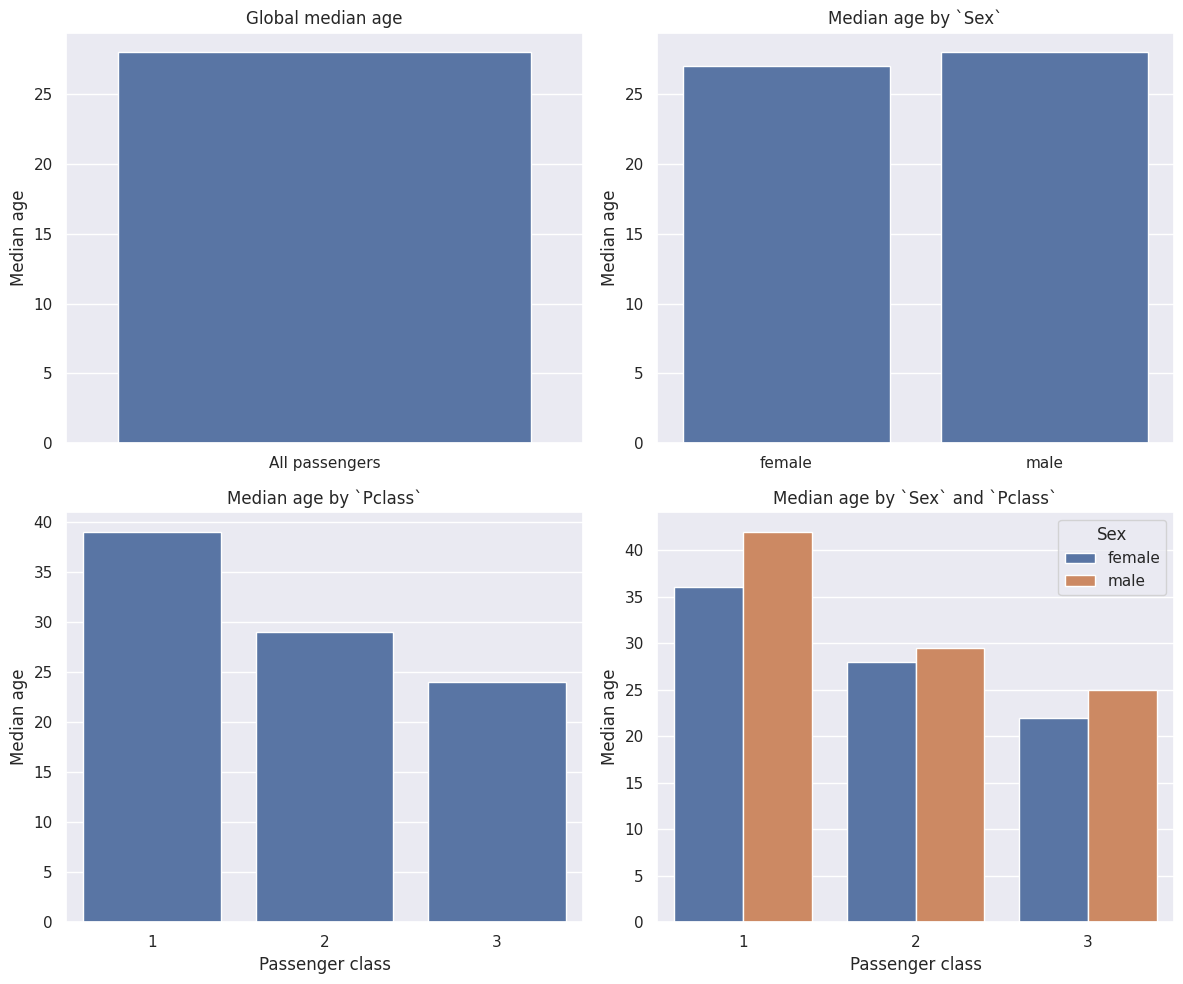

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Global median
global_median = df_full["Age"].median()

sns.barplot(
    x=["All passengers"],
    y=[global_median],
    ax=axes[0, 0]
)

axes[0, 0].set_title("Global median age")
axes[0, 0].set_ylabel("Median age")
axes[0, 0].set_xlabel("")

# Median by Sex
median_by_sex = (
    df_full
    .groupby("Sex")["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_sex,
    x="Sex",
    y="Age",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Median age by `Sex`")
axes[0, 1].set_ylabel("Median age")
axes[0, 1].set_xlabel("")

# Median by Pclass
median_by_class = (
    df_full
    .groupby("Pclass")["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_class,
    x="Pclass",
    y="Age",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Median age by `Pclass`")
axes[1, 0].set_ylabel("Median age")
axes[1, 0].set_xlabel("Passenger class")

# Median by Sex and Pclass
median_by_group = (
    df_full
    .groupby(["Pclass", "Sex"])["Age"]
    .median()
    .reset_index()
)

sns.barplot(
    data=median_by_group,
    x="Pclass",
    y="Age",
    hue="Sex",
    ax=axes[1, 1]
)

axes[1, 1].set_title("Median age by `Sex` and `Pclass`")
axes[1, 1].set_ylabel("Median age")
axes[1, 1].set_xlabel("Passenger class")

plt.tight_layout()
plt.show()

Os gráficos acima mostram que a mediana da idade varia consideravelmente entre as classes de passageiros e, em menor grau, entre homens e mulheres. Embora o uso de uma única mediana global forneça uma solução simples, essa abordagem ignoraria essas diferenças, atribuindo a mesma idade a passageiros pertencentes a grupos com distribuições etárias claramente distintas.

Com base nessa análise, optamos por imputar os valores faltantes de `Age` utilizando a mediana da idade calculada para cada grupo definido pela combinação (`Pclass`, `Sex`). Essa abordagem preserva melhor a estrutura subjacente dos dados, mantendo-se ao mesmo tempo simples, interpretável e computacionalmente eficiente.

In [12]:
df_full["Age"] = (
    df_full.groupby(["Pclass", "Sex"])["Age"]
           .transform(lambda s: s.fillna(s.median()))
)

### Fill missing values in `Embarked` with the mode

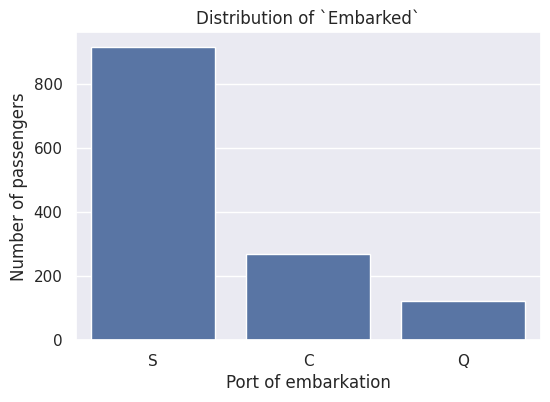

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_full,
    x="Embarked",
    order=df_full["Embarked"].value_counts().index
)

plt.title("Distribution of `Embarked`")
plt.xlabel("Port of embarkation")
plt.ylabel("Number of passengers")

plt.show()

A figura acima mostra que a maioria dos passageiros embarcou em **Southampton (`S`)**, tornando essa a categoria mais frequente da variável `Embarked` com ampla vantagem. Como existem apenas alguns valores faltantes, substituí-los pela categoria mais frequente constitui uma estratégia de imputação simples e adequada, com impacto praticamente desprezível sobre a distribuição geral dos dados.

In [14]:
# Fill missing values in `Embarked` with the most frequent category
embarked_mode = df_full["Embarked"].mode()[0]
df_full["Embarked"] = df_full["Embarked"].fillna(embarked_mode)

### Preenchendo `Fare` com a mediana

In [15]:
# Impute missing Fare with the median value
df_full["Fare"] = df_full["Fare"].fillna(
    df_full["Fare"].median()
)

### Removendo `Cabin`

O atributo `Cabin` contém valores faltantes para a maioria dos passageiros. Embora seja possível extrair informações potencialmente úteis a partir do identificador da cabine (como o convés), a grande proporção de registros ausentes exigiria técnicas mais sofisticadas de imputação ou engenharia de atributos.

Neste tutorial, optamos por remover `Cabin` da análise e concentrar nossa atenção em atributos mais completos e de pré-processamento mais simples. Essa decisão simplifica o pipeline de modelagem, preservando as variáveis que carregam a maior parte da informação preditiva.

In [16]:
# Remove the `Cabin` column from the datasets
for df in [df_full, df_train, df_test]:
    if "Cabin" in df.columns:
        df.drop(columns="Cabin", inplace=True)

# Remove the `Cabin` row from the feature description table
df_features = df_features[df_features["Name"] != "Cabin"].reset_index(drop=True)

# Remove `Cabin` from the feature list
if "Cabin" in features:
    features.remove("Cabin")

df_features

,Name,Type,Category,Source,Description
0,Pclass,numerical,original,Pclass,"Passenger ticket class (`1` = First, `2` = Sec..."
1,Name,categorical,original,Name,Passenger's full name.
2,Sex,categorical,original,Sex,Passenger's sex (`male` or `female`).
3,Age,numerical,original,Age,Passenger's age in years. Fractional values re...
4,SibSp,numerical,original,SibSp,Number of siblings and spouses aboard the Tita...
5,Parch,numerical,original,Parch,Number of parents and children aboard the Tita...
6,Ticket,categorical,original,Ticket,Ticket number.
7,Fare,numerical,original,Fare,Passenger fare.
8,Embarked,categorical,original,Embarked,"Port of embarkation (`C` = Cherbourg, `Q` = Qu..."


## Relação entre os atributos e a sobrevivência

Após tratar os valores faltantes, podemos começar a explorar como cada atributo se relaciona com a variável alvo, `Survived`. O objetivo desta análise não é estabelecer relações de causalidade, mas identificar padrões que possam ajudar um modelo de classificação a distinguir entre passageiros que sobreviveram e aqueles que não sobreviveram.

Ao longo desta seção, examinamos a distribuição da sobrevivência em relação aos atributos disponíveis e destacamos as variáveis que parecem carregar informações preditivas. Essas observações também orientarão as etapas de engenharia de atributos e desenvolvimento dos modelos do projeto.

### `Sex`

Uma das primeiras perguntas que podemos fazer é se o sexo do passageiro esteve associado à sobrevivência. Como `Sex` é uma variável categórica, uma comparação simples das taxas de sobrevivência entre homens e mulheres fornece uma maneira intuitiva de avaliar seu poder preditivo.

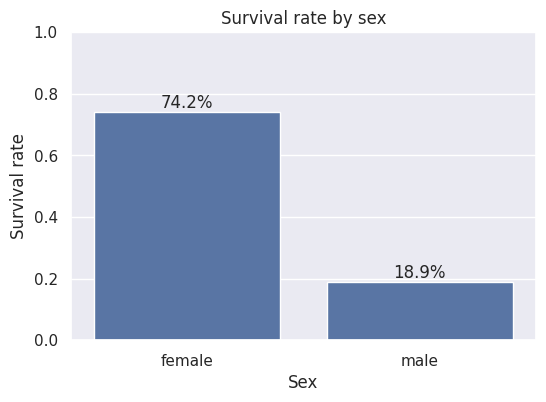

In [17]:
survival_by_sex = (
    df_train
    .groupby("Sex")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=survival_by_sex,
    x="Sex",
    y="Survived"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )


plt.title("Survival rate by sex")
plt.xlabel("Sex")
plt.ylabel("Survival rate")

plt.ylim(0, 1)

plt.show()

A figura acima mostra uma diferença marcante nas taxas de sobrevivência entre passageiros homens e mulheres. Enquanto apenas uma pequena fração dos homens sobreviveu, a maioria das mulheres sobreviveu.

Esse padrão reflete a política de evacuação historicamente descrita como *"mulheres e crianças primeiro"*, que priorizou mulheres durante o processo de embarque nos botes salva-vidas. Do ponto de vista de aprendizado de máquina, esse resultado indica que `Sex` provavelmente é um dos atributos mais informativos para prever a sobrevivência dos passageiros e, portanto, deve ser mantido como uma característica importante em nossos modelos de classificação.

### `Age`

A idade pode ter desempenhado um papel importante na sobrevivência, especialmente considerando os relatos históricos sobre os procedimentos de evacuação que priorizavam mulheres e crianças. Nesta seção, investigamos a relação entre a idade dos passageiros e a sobrevivência para determinar se a idade fornece informações preditivas úteis.

Para explorar essa relação, comparamos as distribuições de idade dos passageiros que sobreviveram com as daqueles que não sobreviveram. A apresentação das duas distribuições lado a lado permite identificar diferenças em suas formas gerais, evitando a poluição visual que pode surgir ao sobrepor histogramas.

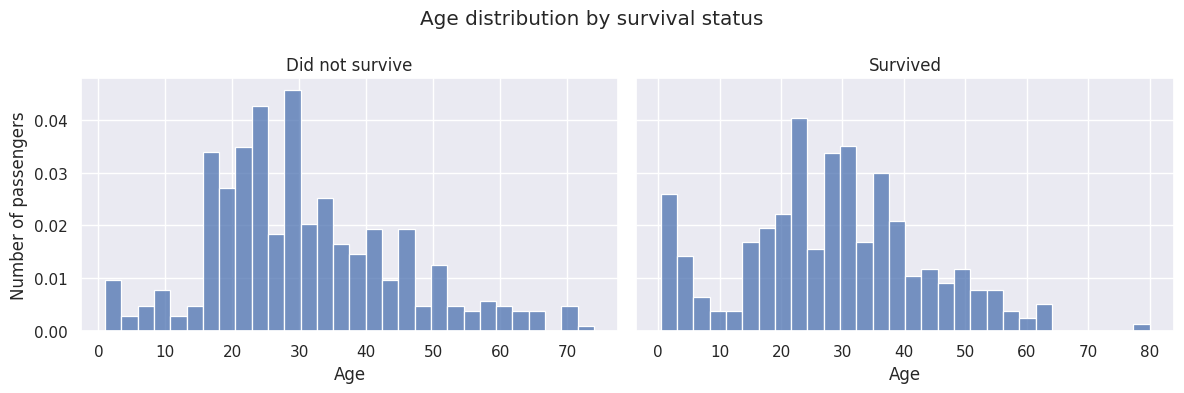

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Passengers who did not survive
sns.histplot(
    data=df_train[df_train["Survived"] == 0],
    stat="density",
    x="Age",
    bins=30,
    ax=axes[0]
)

axes[0].set_title("Did not survive")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of passengers")

# Passengers who survived
sns.histplot(
    data=df_train[df_train["Survived"] == 1],
    stat="density",
    x="Age",
    bins=30,
    ax=axes[1]
)

axes[1].set_title("Survived")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("")

plt.suptitle("Age distribution by survival status")
plt.tight_layout()

plt.show()

Os histogramas mostram que as distribuições de idade dos sobreviventes e dos não sobreviventes apresentam uma grande sobreposição, indicando que `Age` isoladamente não é suficiente para distinguir os dois grupos. Ainda assim, existem diferenças perceptíveis. Em particular, crianças pequenas parecem ter sobrevivido em taxas mais elevadas, enquanto a distribuição dos não sobreviventes apresenta maior concentração entre adultos jovens e de meia-idade.

Diferentemente de `Sex`, que apresenta uma relação muito forte com a sobrevivência, o poder preditivo de `Age` parece ser mais sutil. Mesmo assim, as diferenças observadas sugerem que a idade fornece informações úteis e deve ser mantida como atributo em nossos modelos de classificação. Combinada com outras variáveis, como `Sex` e `Pclass`, é provável que contribua para melhorar o desempenho preditivo dos modelos.

### `Pclass`

A classe do passageiro é frequentemente considerada uma variável associada ao nível socioeconômico e pode ter influenciado o acesso dos passageiros aos botes salva-vidas e a outros recursos durante a evacuação. Nesta seção, examinamos como as taxas de sobrevivência variam entre as três classes de passageiros para determinar se `Pclass` é um atributo preditivo relevante.

Para investigar essa relação, calculamos a taxa de sobrevivência para cada classe de passageiro. Comparar as taxas de sobrevivência, em vez do número absoluto de passageiros, permite analisar a probabilidade de sobrevivência dentro de cada classe, independentemente da quantidade de passageiros viajando em cada uma delas.

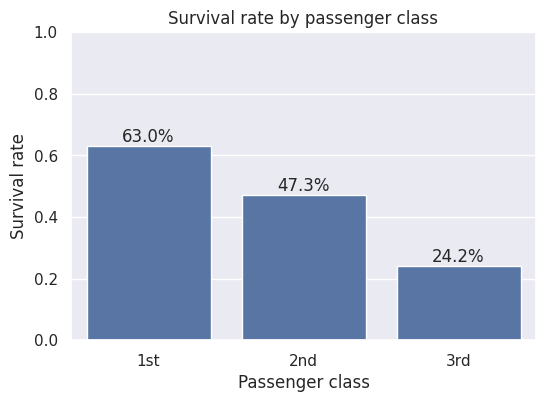

In [19]:
survival_by_class = (
    df_train
    .groupby("Pclass")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=survival_by_class,
    x="Pclass",
    y="Survived"
)

# Annotate bars with percentages
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Survival rate by passenger class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")

plt.ylim(0, 1)
plt.xticks([0, 1, 2], ["1st", "2nd", "3rd"])

plt.show()

A figura acima revela uma relação clara entre a classe do passageiro e a sobrevivência. Passageiros da primeira classe apresentaram a maior taxa de sobrevivência, seguidos por aqueles viajando na segunda classe, enquanto passageiros da terceira classe apresentaram a menor taxa de sobrevivência, com uma diferença considerável em relação às demais classes.

Esse padrão sugere que fatores socioeconômicos desempenharam um papel importante durante a evacuação. Passageiros das classes mais altas provavelmente possuíam cabines localizadas mais próximas ao convés dos botes, maior acesso às informações ou melhores oportunidades de embarcar nos botes salva-vidas antes que eles atingissem sua capacidade máxima.

Do ponto de vista de aprendizado de máquina, `Pclass` parece ser um dos atributos mais fortes para prever a sobrevivência. Portanto, esse atributo deve ser mantido como uma característica importante em nossos modelos de classificação.


### `Fare`

O atributo `Fare` representa o valor pago pela passagem do passageiro. Como os preços das passagens estavam geralmente associados à classe do passageiro e à localização da cabine, eles também podem estar indiretamente relacionados à sobrevivência. Nesta seção, exploramos essa relação comparando as distribuições das tarifas entre sobreviventes e não sobreviventes.

Como `Fare` é uma variável contínua com uma distribuição altamente assimétrica, um box plot fornece uma maneira conveniente de comparar as tarifas pagas pelos sobreviventes e pelos não sobreviventes. Essa visualização resume a distribuição de cada grupo, destacando diferenças nos valores típicos das tarifas e a presença de valores extremos.


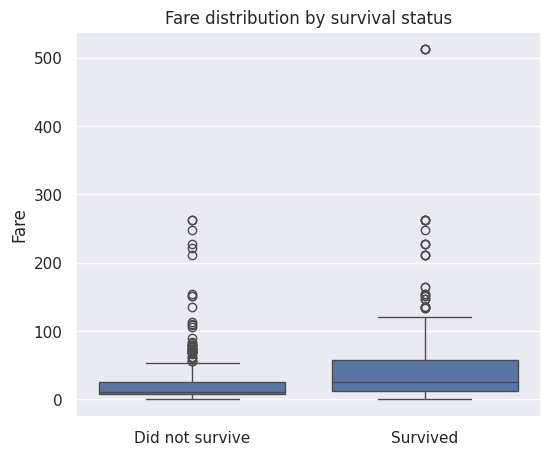

In [20]:
plt.figure(figsize=(6, 5))

sns.boxplot(
    data=df_train,
    x="Survived",
    y="Fare"
)

plt.xticks([0, 1], ["Did not survive", "Survived"])
plt.title("Fare distribution by survival status")
plt.xlabel("")
plt.ylabel("Fare")

plt.show()

O box plot mostra que os passageiros que sobreviveram geralmente pagaram tarifas mais altas do que aqueles que não sobreviveram. Embora as duas distribuições apresentem uma sobreposição considerável, a mediana da tarifa é claramente maior entre os sobreviventes, e uma proporção maior de passageiros com tarifas elevadas sobreviveu.

Essa relação não é surpreendente, pois o valor da passagem está fortemente associado à classe do passageiro. Tarifas mais altas eram geralmente pagas por passageiros da primeira classe, que também apresentaram taxas de sobrevivência significativamente maiores. Consequentemente, `Fare` provavelmente fornece informações preditivas úteis, tanto isoladamente quanto em combinação com atributos relacionados, como `Pclass`.


### `Embarked`

Os passageiros embarcaram no Titanic em um dos três portos disponíveis: Cherbourg (`C`), Queenstown (`Q`) ou Southampton (`S`). Diferenças no perfil dos passageiros entre esses portos podem ter influenciado as taxas de sobrevivência. Por isso, comparamos a proporção de sobreviventes para cada porto de embarque.

Assim como nos demais atributos categóricos, comparamos a taxa de sobrevivência para cada porto de embarque em vez do número absoluto de passageiros. Isso permite avaliar se passageiros que embarcaram em portos diferentes apresentaram probabilidades distintas de sobrevivência.


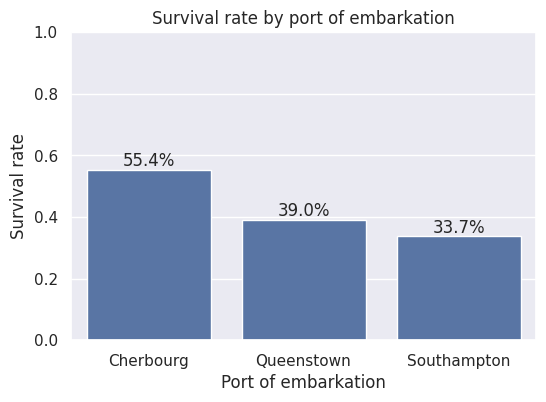

In [21]:
survival_by_embarked = (
    df_train
    .groupby("Embarked")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=survival_by_embarked,
    x="Embarked",
    y="Survived",
    order=["C", "Q", "S"]
)

# Annotate bars with percentages
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

ax.set_xticks(range(3))
ax.set_xticklabels(["Cherbourg", "Queenstown", "Southampton"])

plt.title("Survival rate by port of embarkation")
plt.xlabel("Port of embarkation")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

A figura acima mostra que as taxas de sobrevivência variaram entre os três portos de embarque. Passageiros que embarcaram em Cherbourg apresentaram a maior taxa de sobrevivência, enquanto aqueles que embarcaram em Southampton apresentaram a menor. Queenstown ficou em uma posição intermediária, embora seja representado por um número de passageiros muito menor.

Essas diferenças provavelmente não são causadas pelo porto de embarque em si. Em vez disso, elas podem refletir diferenças nas características dos passageiros que embarcaram em cada local. Uma possível explicação é que os três portos atendiam diferentes proporções de passageiros da primeira, segunda e terceira classes, sendo que já observamos que a classe do passageiro está fortemente associada à sobrevivência.

Para investigar essa hipótese, examinaremos a composição das classes de passageiros em cada porto de embarque. Se um porto apresentar, por exemplo, uma proporção significativamente maior de passageiros da primeira classe, isso poderia naturalmente resultar em uma taxa geral de sobrevivência mais elevada.


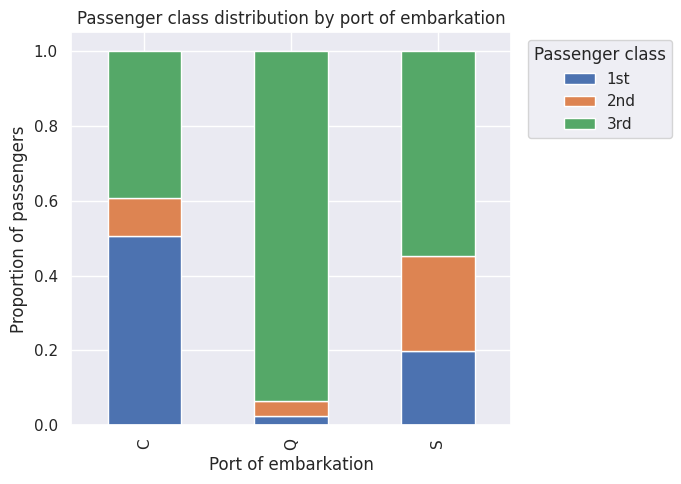

In [22]:
class_dist = pd.crosstab(
    df_train["Embarked"],
    df_train["Pclass"],
    normalize="index"
)

class_dist.columns = ["1st", "2nd", "3rd"]

ax = class_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(7, 5)
)

plt.title("Passenger class distribution by port of embarkation")
plt.xlabel("Port of embarkation")
plt.ylabel("Proportion of passengers")

ax.legend(
    title="Passenger class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

O gráfico de barras empilhadas confirma essa hipótese. Cherbourg apresentou uma proporção significativamente maior de passageiros da primeira classe, enquanto Southampton era dominado por passageiros da terceira classe. Como já observamos que a classe do passageiro está fortemente associada à sobrevivência, grande parte do efeito aparente de `Embarked` pode ser explicada pela sua relação com `Pclass`.

Embora `Embarked` não seja, portanto, uma explicação independente para a sobrevivência, ele ainda carrega informações preditivas úteis, pois captura diferenças na composição da população de passageiros. Modelos de aprendizado de máquina podem explorar essas informações, mesmo quando elas estão correlacionadas com outros atributos.


### `SibSp`

O atributo `SibSp` registra o número de irmãos e cônjuges viajando com cada passageiro. Viajar com familiares pode ter influenciado as decisões durante a evacuação e os resultados de sobrevivência. Nesta seção, investigamos se o número de irmãos ou cônjuges acompanhantes está associado à sobrevivência.

Para explorar essa relação, calculamos a taxa de sobrevivência para cada valor de `SibSp`. Isso permite examinar se viajar sozinho ou com diferentes quantidades de irmãos ou cônjuges estava associado a uma maior ou menor probabilidade de sobrevivência.


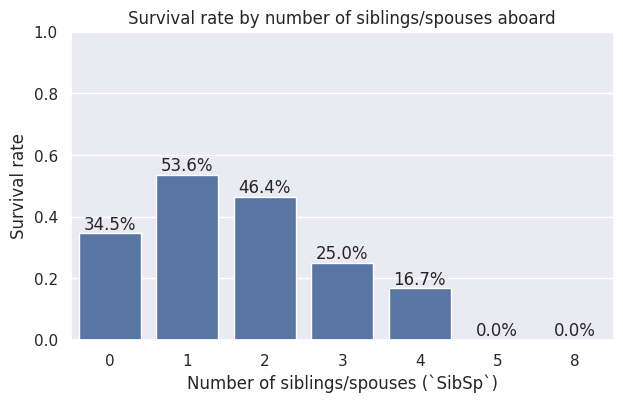

In [23]:
survival_by_sibsp = (
    df_train
    .groupby("SibSp")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=survival_by_sibsp,
    x="SibSp",
    y="Survived"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Survival rate by number of siblings/spouses aboard")
plt.xlabel("Number of siblings/spouses (`SibSp`)")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

A relação entre `SibSp` e a sobrevivência é mais complexa do que aquelas observadas para `Sex` ou `Pclass`. Passageiros viajando com um ou dois irmãos ou cônjuges geralmente apresentaram taxas de sobrevivência maiores do que aqueles viajando sozinhos. No entanto, as taxas de sobrevivência diminuíram para passageiros viajando com grupos familiares maiores.

Esse padrão sugere que a presença de familiares pode ter sido benéfica até certo ponto, enquanto grupos familiares muito grandes podem ter enfrentado dificuldades adicionais durante a evacuação. Em vez de o valor exato de `SibSp` ser o fator mais importante, os resultados indicam que o contexto familiar geral pode ser mais informativo. Essa observação motiva a criação de atributos derivados, como o tamanho total da família, na próxima etapa do projeto.


### `Parch`

O atributo `Parch` indica o número de pais e filhos viajando com cada passageiro. Assim como `SibSp`, ele fornece informações sobre as relações familiares a bordo do Titanic. Nesta seção, examinamos se viajar com pais ou filhos está associado a diferenças nas taxas de sobrevivência.

Para analisar essa relação, calculamos a taxa de sobrevivência para cada valor de `Parch`. Isso permite avaliar se viajar com pais ou filhos esteve associado a diferenças na probabilidade de sobrevivência.


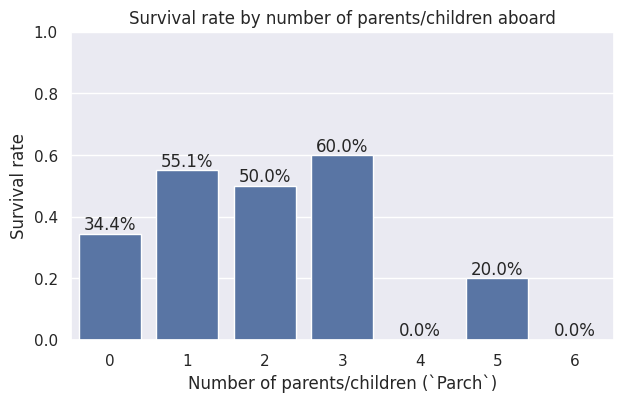

In [24]:
survival_by_parch = (
    df_train
    .groupby("Parch")["Survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=survival_by_parch,
    x="Parch",
    y="Survived"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("Survival rate by number of parents/children aboard")
plt.xlabel("Number of parents/children (`Parch`)")
plt.ylabel("Survival rate")
plt.ylim(0, 1)

plt.show()

A relação entre `Parch` e a sobrevivência apresenta um padrão semelhante ao observado para `SibSp`. Passageiros viajando com um ou dois pais ou filhos tendem a apresentar taxas de sobrevivência maiores do que aqueles viajando sozinhos. No entanto, as taxas de sobrevivência diminuem para passageiros viajando com grupos familiares maiores.

Esses resultados sugerem que uma presença familiar moderada pode ter sido benéfica durante a evacuação, enquanto grupos familiares maiores podem ter enfrentado dificuldades adicionais de coordenação. Considerando esses resultados em conjunto com `SibSp`, reforça-se a ideia de que a estrutura familiar é um fator importante, mas que não é totalmente capturada por nenhum dos dois atributos individualmente. Isso motiva a criação de um atributo combinado representando o tamanho total da família.


### `Ticket`

O atributo `Ticket` contém o número da passagem do passageiro. Embora pareça ser apenas um identificador, os números das passagens podem carregar informações sobre grupos de reserva ou organização da viagem. Nesta seção, realizamos uma breve inspeção para determinar se esse atributo contém informações preditivas úteis em sua forma original.

Para compreender melhor esse atributo, primeiro inspecionamos a distribuição dos valores de `Ticket`. Em particular, verificamos se existem números de passagem repetidos ou padrões identificáveis que possam indicar reservas em grupo ou arranjos de viagem compartilhados.


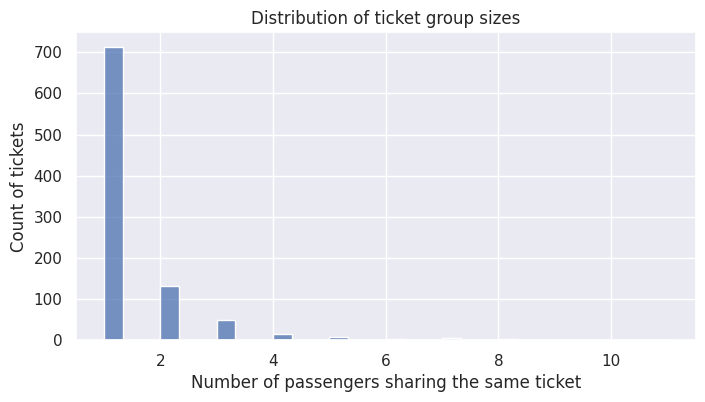

In [25]:
ticket_counts = df_full["Ticket"].value_counts()

plt.figure(figsize=(8, 4))

sns.histplot(ticket_counts, bins=30)

plt.title("Distribution of ticket group sizes")
plt.xlabel("Number of passengers sharing the same ticket")
plt.ylabel("Count of tickets")

plt.show()

A inspeção revela que muitos valores de `Ticket` são únicos, enquanto algumas passagens são compartilhadas por múltiplos passageiros. Isso sugere que `Ticket` pode carregar informações parciais sobre viagens em grupo, em vez de funcionar apenas como um identificador.

No entanto, sua estrutura não é imediatamente interpretável em sua forma bruta, e o atributo apresenta uma cardinalidade muito alta com pouco sinal preditivo direto. Por esse motivo, deixamos transformações mais detalhadas de `Ticket` (como a extração de prefixos ou o agrupamento de passageiros por números de passagem compartilhados) para a etapa de engenharia de atributos, onde seu potencial preditivo poderá ser explorado de forma mais sistemática.


### `Name`

À primeira vista, `Name` parece ser apenas um identificador e, portanto, não diretamente útil para previsão. No entanto, os nomes dos passageiros contêm uma estrutura implícita, especialmente títulos de tratamento como `Mr.`, `Mrs.`, `Miss` e `Master`, que podem refletir características demográficas e sociais associadas à sobrevivência.

Para investigar essa possibilidade, extraímos e analisamos a distribuição dos títulos dos passageiros.


In [26]:
df_with_title = df_full.copy()
df_with_title["Title"] = df_with_title["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)

title_counts = df_with_title["Title"].value_counts()
title_counts.head(20)

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64

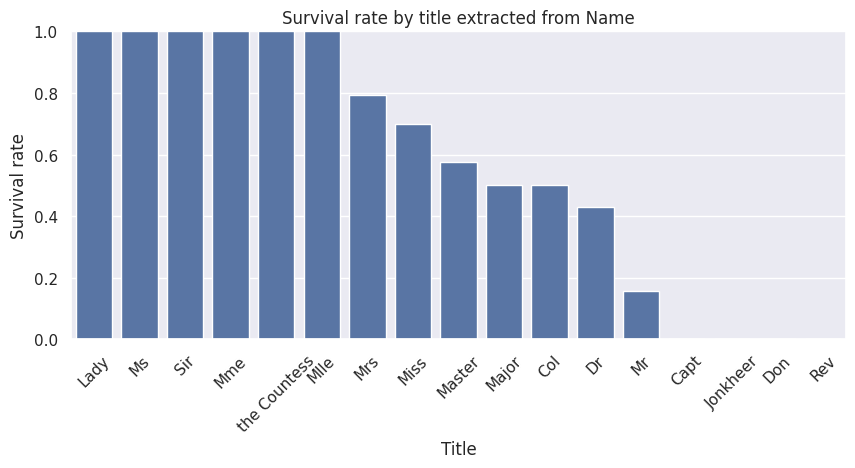

In [27]:
df_with_title = df_with_title.loc[df_with_title["IsTrainSet"]]

survival_by_title = (
    df_with_title
    .groupby("Title")["Survived"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 4))

ax = sns.barplot(
    data=survival_by_title,
    x="Title",
    y="Survived"
)

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.title("Survival rate by title extracted from Name")
plt.xlabel("Title")
plt.ylabel("Survival rate")

plt.show()

Entre os títulos extraídos, também observamos um pequeno número de categorias raras relacionadas a status militar ou profissional, como `Captain`.

No conjunto de dados do Titanic, o título `Captain` corresponde ao Capitão Edward Smith, comandante do navio, que não sobreviveu ao desastre. Embora seja uma única observação, esse caso ilustra que alguns títulos podem carregar informações contextuais relevantes, mesmo quando aparecem apenas uma vez no conjunto de dados.

Os resultados mostram diferenças claras nas taxas de sobrevivência entre os títulos dos passageiros. Títulos associados a mulheres e crianças, como `Mrs.`, `Miss` e `Master`, tendem a apresentar taxas de sobrevivência mais elevadas, enquanto `Mr.` está associado a uma taxa de sobrevivência consideravelmente menor.

Títulos menos frequentes também aparecem no conjunto de dados e refletem variações de status social ou funções desempenhadas a bordo. Embora muitas dessas categorias contenham poucas observações, elas ainda podem codificar informações úteis sobre a identidade e o contexto dos passageiros.

De forma geral, esses resultados confirmam que `Name` contém sinais estruturados e informativos além de uma simples identificação. Em particular, o atributo extraído `Title` captura informações demográficas e sociais que provavelmente contribuirão para melhorar o desempenho preditivo. Por esse motivo, revisitaremos `Name` durante a etapa de engenharia de atributos para construir variáveis mais informativas.


### Resumo dos Resultados

A análise exploratória revelou diversos atributos fortemente associados à sobrevivência dos passageiros.

* `Sex` é o preditor individual mais forte, com passageiros do sexo feminino apresentando taxas de sobrevivência significativamente maiores.
* `Pclass` também é altamente informativo, com passageiros da primeira classe apresentando maior frequência de sobrevivência em comparação com aqueles da segunda e terceira classes.
* `Age` apresenta uma relação mais fraca, porém perceptível, com a sobrevivência, especialmente no caso de crianças pequenas.
* `Fare` está positivamente associado à sobrevivência, embora essa relação seja parcialmente explicada por sua correlação com `Pclass`.
* `Embarked` apresenta diferenças moderadas nas taxas de sobrevivência entre os portos de embarque, provavelmente refletindo diferenças na composição dos passageiros, e não o local de embarque em si.
* `SibSp` e `Parch` sugerem que a estrutura familiar pode influenciar a sobrevivência, motivando a criação de atributos derivados como `FamilySize` e `IsAlone`.
* `Name` contém informações estruturadas, especialmente os títulos dos passageiros, que apresentam diferenças claras nas taxas de sobrevivência entre grupos sociais e demográficos. Esses padrões serão explorados posteriormente na etapa de engenharia de atributos por meio da criação de um atributo específico `Title`.

Essas observações fornecem uma compreensão inicial importante sobre o conjunto de dados e orientam diretamente as escolhas de engenharia de atributos realizadas no [próximo notebook](02_feature_engineering.ipynb).


## Salvando o conjunto de dados processado

Neste estágio, todos os problemas de qualidade de dados identificados foram tratados, incluindo o tratamento de valores faltantes e a remoção ou transformação de atributos que não são diretamente utilizáveis em sua forma original. O conjunto de dados encontra-se agora em um estado limpo e consistente.

Para evitar a repetição dessas etapas de pré-processamento nos notebooks seguintes, salvamos os dados processados em disco. Isso garante que as etapas de engenharia de atributos e modelagem utilizem uma entrada estável e reprodutível.

O próximo notebook utilizará esse conjunto de dados como base para realizar a engenharia de atributos, incluindo a criação de variáveis derivadas como `Title`, `FamilySize` e outras transformações motivadas pela análise exploratória.


In [28]:
# Save dataframes in parquet format to preserve data types
df_full.to_parquet(
    "../data/processed/01_data.parquet",
    index=False
)
df_features.to_parquet(
    "../data/processed/01_features.parquet",
    index=False
)

## Considerações finais

Nesta análise exploratória, examinamos a estrutura do conjunto de dados Titanic, tratamos os valores faltantes e investigamos como os atributos individuais se relacionam com a sobrevivência dos passageiros.

A análise revelou diversos sinais importantes, especialmente em `Sex`, `Pclass` e `Age`, além de padrões mais sutis em atributos como `Fare`, `Embarked` e variáveis relacionadas à família (`SibSp`, `Parch`). Além disso, identificamos que tanto `Name` quanto `Ticket` contêm informações estruturadas que não são diretamente utilizáveis em sua forma original, mas que podem ser transformadas em atributos mais informativos.

Essas observações fornecem a base para a próxima etapa do projeto.

No [próximo notebook](02_feature_engineering.ipynb), iremos focar na engenharia de atributos. Isso inclui a codificação de variáveis categóricas, a extração de informações de `Name` (como os títulos dos passageiros), a criação de atributos baseados em relações familiares e a transformação do conjunto de dados para um formato adequado aos modelos de aprendizado de máquina.
